In [10]:
import networkx as nx
import numpy as np
import string
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

In [2]:
nameToId : dict[str:int] = {}
idToName : dict[int:str] = {}
with open("allPageRank/nameToId.txt") as f:
    for line in f.readlines():
        nom, w_id = line.split(" :: ")
        nameToId[nom] = int(w_id)
        idToName[int(w_id)] = nom

id_to_pos = {id: i for i, id in enumerate(idToName)}
pos_to_id = {i: id for i, id in enumerate(idToName)}

In [3]:
def carregar_conexions_valles() -> dict[int:list[int]]:
    valles_connections:dict[int:list[int]] = {}

    with open("allPageRank/entriesConnections.txt") as f:
        for line in f.read().split("\n"):
            if line == "": continue
            source, connections = line.split(" :: ")
            if not len(connections) == 0:
                connections = connections.split(" ")
            if int(source) in idToName.keys():
                valles_connections[int(source)] = [int(conn) for conn in connections if not conn == ""]

    for (pob, conn) in valles_connections.items():
        valles_connections[pob] = list(filter(lambda x: x in idToName.keys(), conn))

    return valles_connections

def conexions_a_matriu(matriu_dajacencia: dict[int:list[int]]) -> np.matrix:
    valles_matrix = np.zeros((len(matriu_dajacencia), len(matriu_dajacencia)))

    for (pob, conn) in matriu_dajacencia.items():
        if len(conn) == 0: continue
        for dest in conn:
            valles_matrix[id_to_pos[dest]][id_to_pos[pob]] = 1/len(conn)
    
    return valles_matrix


def arreglar_inconexos(matriu_dajacencia:np.matrix) -> np.matrix:
    for i, col in enumerate(matriu_dajacencia.T):
        if col.sum() == 0:
            for j in range(len(col)):
                matriu_dajacencia[j][i] = 1/len(id_to_pos)
    
    return matriu_dajacencia

3721


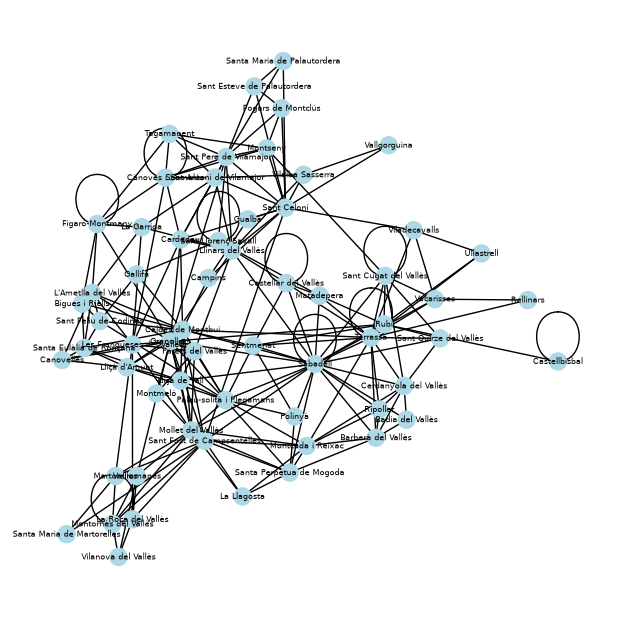

In [37]:
def mostrar_graf(matriu_dajacencia:np.matrix, mides_nodes:list[int]|None=None) -> None:
    print(matriu_dajacencia.size)
    if mides_nodes is None:
        mides_nodes = [150 for _ in range(matriu_dajacencia.shape[0])]

    G = nx.from_numpy_array(matriu_dajacencia)

    # Dibuixar
    plt.figure(figsize=(6, 6))
    nx.draw(
        G,
        labels={i: idToName[id] for id, i in id_to_pos.items()},
        with_labels=True,
        node_color="lightblue",
        node_size=mides_nodes,
        font_size=6
    )

    plt.show()

valles_connections = carregar_conexions_valles()
valles_matrix_inconex = conexions_a_matriu(valles_connections)

mostrar_graf(valles_matrix_inconex)


In [21]:
def damping(matriu_dajacencia:np.matrix, alpha) -> np.matrix:
    N = matriu_dajacencia.shape[0]

    damping_matrix = np.ones_like(matriu_dajacencia)/N

    M = alpha*matriu_dajacencia + (1-alpha)*damping_matrix

    return M

In [22]:
def autovector_i_autovalor_dominants(matriu_dajacencia:np.matrix): 
    vaps, veps = np.linalg.eig(matriu_dajacencia)
    
    dom_vap = max(vaps)
    assert np.real(dom_vap) > 0 and not np.iscomplex(dom_vap)
    for vap in vaps: assert dom_vap >= np.abs(vap)
    assert np.count_nonzero(vaps == dom_vap) == 1

    idx = np.where(vaps == dom_vap)
    dom_vap = np.real(vaps[idx])
    dom_vep = veps[:, idx]
    return dom_vap, dom_vep

In [31]:
def format_resultat(resultat, alpha, truncar:int|none=5):
    if truncar == None: truncar = len(resultat)
    resultat = {pos_to_id[i]: resultat[i] for i in range(len(resultat))}
    print(f"Resultats amb dampening factor {alpha}")
    for id, res in sorted(resultat.items(), key=lambda i: abs(i[1]), reverse=True)[:truncar]:
        print(f"\t{idToName[id]}: {np.real(res)[0][0]}")


def pagerank_nomes_valles(alpha, valles_connections, valles_matrix, truncar:int|None=5):
    valles_matrix = damping(valles_matrix, alpha)

    vap, vep = autovector_i_autovalor_dominants(valles_matrix)
    
    resultat = vep/vep.sum()

    format_resultat(resultat, alpha, truncar=truncar)

    return resultat



In [ ]:
valles_connections = carregar_conexions_valles()
valles_matrix_inconex = conexions_a_matriu(valles_connections)
valles_matrix = arreglar_inconexos(valles_matrix)

pagerank_nomes_valles(0.5, valles_connections, valles_matrix)
pagerank_nomes_valles(0.7, valles_connections, valles_matrix)
pagerank_nomes_valles(0.85, valles_connections, valles_matrix)
pagerank_nomes_valles(0.99, valles_connections, valles_matrix)

pass

Resultats amb dampening factor 0.5
	Sabadell: 0.04149579184534232
	Caldes de Montbui: 0.039210027163233505
	Cànoves i Samalús: 0.03824819060833947
	Granollers: 0.03784201407808212
	Les Franqueses del Vallès: 0.02904067598110247
Resultats amb dampening factor 0.7
	Cànoves i Samalús: 0.06642385706193192
	Sabadell: 0.049883762378775634
	Granollers: 0.04436714321323235
	Caldes de Montbui: 0.04253503274069979
	Les Franqueses del Vallès: 0.03811484186691132
Resultats amb dampening factor 0.85
	Cànoves i Samalús: 0.12467793089820592
	Sabadell: 0.05159506773468779
	Granollers: 0.045264893297594554
	Vilanova del Vallès: 0.045154894800037086
	Les Franqueses del Vallès: 0.04299265930227153
Resultats amb dampening factor 0.99
	Cànoves i Samalús: 0.5521119843155807
	Vilanova del Vallès: 0.07338332917325292
	Montornès del Vallès: 0.056199091524372094
	La Roca del Vallès: 0.05615627059259
	Castellbisbal: 0.04289569922055392


Resultats amb dampening factor 0.95
	Cànoves i Samalús: 0.26586159032793
	Vilanova del Vallès: 0.07292912478866696
	Montornès del Vallès: 0.0578314520423147
3721


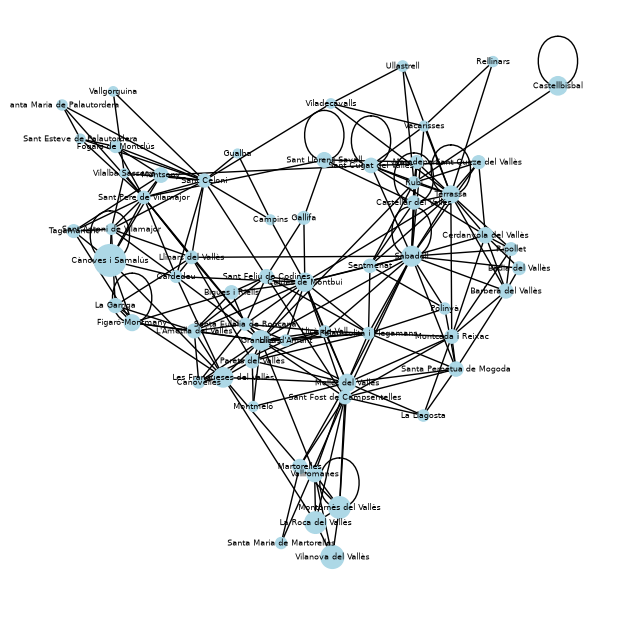

In [57]:
def pagerank_dibuix(alpha, valles_connections, valles_matrix, valles_matrix_inconex):
    pagerank = pagerank_nomes_valles(alpha, valles_connections, valles_matrix, truncar=3)
    mides_nodes = list(map(lambda x: int(np.sqrt(np.real(x[0][0]))*1000), pagerank))
    mostrar_graf(valles_matrix_inconex, mides_nodes=mides_nodes)
    
pagerank_dibuix(0.95, valles_connections, valles_matrix, valles_matrix_inconex)

## Amb tot el graf de la Viquipèdia

### Explicació del funcionament del programa
Primer, per compilar getAllConnectionEntries.cpp (i també namesAndIds.cpp) s'ha de fer la comanda `g++ -std=c++17 -I/opt/homebrew/include ./getAllConnectionEntries.cpp -L/opt/homebrew/lib -lzim -o getAllConnectionEntries` i després executar-ho amb `./getAllConnectionEntries ./wikipedia_ca_all_nopic.zim` (ídem en el cas de namesAndIds.cpp). 

Els resultats obtinguts amb aquset programa ja son proporcionats (entriesConnections.txt i nameToID.txt) ja que per fer aixó d'adalt s'hauria de instalar la llibreria zim, que és la que llegeix els fitxers, descarregar el fitxer `wikipedia_ca_all_nopic.zim` i executar el programa (triga aproximadament 15 minuts). És per aixó que els resultats d'aquesta part son proporcionats. 

Després d'alló, només queda fer el PageRank, primer compilar amb `g++ -std=c++17 ./pageRanker.cpp -o pageRanker` i després amb `./pageRanker <factor>` genera un fitxer amb nom `damping<factor*100>.txt` a `resultatsPageRank` amb resultats ordenats de forma ascendent.

Notem com, en els que hem fet nosaltres quant més gran es el dumping factor més triga en convergir (per a un epsilon de 1e-8):

| d    | Iteracions necessàries|
|------|-----------------------|
| 0.5  | 18                    |
| 0.7  | 29                    |
| 0.85 | 52                    |
| 0.99 | 840                   |


### Analisi del subgraf sobre el PageRank del graf complet

In [9]:
from os import listdir

nom_to_pos : dict[str:list[tuple(int,int)]] = {i:[] for i in nameToId} 

for damp in sorted(listdir("allPageRank/resultatsPageRank")):
    print("\nAmb", float(damp[7:-4])/100, "com a factor d'esmorteïment:")
    i = 0
    with open("allPageRank/resultatsPageRank/" + damp) as f:
        for j, line in enumerate(f.readlines()):
            w_id, punt = line.split(": ")
            if int(w_id) in idToName:
                i += 1
                nom_to_pos[idToName[int(w_id)]].append((i,j))
                if i < 6:
                    print(f"\t {i}.- {idToName[int(w_id)]}: {punt[:-1]} (pos {j} del PageRank del graf complet)")

nom_to_pos_invar : dict[str:int] = {}
nom_to_diferencia_pos : dict[str:int] = {}
nom_to_diferencia_glo_pos : dict[str:int] = {}
for nom, posicions in nom_to_pos.items():
    if all(p[0] == posicions[0][0] for p in posicions):
        nom_to_pos_invar[nom] = posicions[0][0]
    else:
        primer = posicions[0][0]
        ultim = posicions[-1][0]
        nom_to_diferencia_pos[nom] = primer-ultim
    # Per la posició de tot el graf
    primer = posicions[0][1]
    ultim = posicions[-1][1]
    nom_to_diferencia_glo_pos[nom] = primer-ultim

print("\nCiutats sense discusió de posició:")
for nom, pos in sorted(nom_to_pos_invar.items(), key=lambda i: i[1]):
    print("\t-",nom,"a", pos)

print("\nCiutats amb més diferencia de posicions:")
for nom, pos in sorted(nom_to_diferencia_pos.items(), key=lambda i: -abs(i[1]))[:5]:
    print("\t-",nom,"amb", pos, (nom_to_pos[nom][0][0], nom_to_pos[nom][-1][0]))

print("\nCiutats amb més diferencia de posicions sobre el global:")
for nom, pos in sorted(nom_to_diferencia_glo_pos.items(), key=lambda i: -abs(i[1]))[:5]:
    print("\t-",nom,"amb", pos, (nom_to_pos[nom][0][1], nom_to_pos[nom][-1][1]))




Amb 0.5 com a factor d'esmorteïment:
	 1.- Sabadell: 0.000106482 (pos 354 del PageRank del graf complet)
	 2.- Terrassa: 7.54056e-05 (pos 589 del PageRank del graf complet)
	 3.- Sant Cugat del Vallès: 4.46182e-05 (pos 1199 del PageRank del graf complet)
	 4.- Granollers: 3.42856e-05 (pos 1741 del PageRank del graf complet)
	 5.- La Garriga: 2.13281e-05 (pos 3190 del PageRank del graf complet)

Amb 0.7 com a factor d'esmorteïment:
	 1.- Sabadell: 0.000146681 (pos 364 del PageRank del graf complet)
	 2.- Terrassa: 9.73816e-05 (pos 663 del PageRank del graf complet)
	 3.- Sant Cugat del Vallès: 5.42709e-05 (pos 1486 del PageRank del graf complet)
	 4.- Granollers: 4.24501e-05 (pos 2239 del PageRank del graf complet)
	 5.- La Garriga: 2.38732e-05 (pos 4248 del PageRank del graf complet)

Amb 0.85 com a factor d'esmorteïment:
	 1.- Sabadell: 0.000172196 (pos 377 del PageRank del graf complet)
	 2.- Terrassa: 0.000106695 (pos 811 del PageRank del graf complet)
	 3.- Sant Cugat del Vallès: 

Podem veure que hi ha diverses posicions que són indiscutibles, com la de Terrassa, Sabadell, Sant Cugat del Vallès i Granollers a les 4 més importants.

També podem veure com altres amb dúmping factor més baix es veuen afavorits, ja que tenen moltes connexions (Bigues i Riells, i Lliçà d'Amunt), mentre d'altres amb el factor més alt es veuen beneficiades (com Sant Quirze del Vallès o Badia del Vallès) perquè tenen connexions amb nodes de qualitat més alta.

Sobretot Lliçà d'Amunt, veiem que segons la Viquipèdia és una de les que més baixa a la posició global pel canvi del factor.

Amb aquesta metodologia Sabadell és la ciutat més important.